Generating metal:   0%|          | 0/300 [00:00<?, ?it/s]

Generating nonmetal: 100%|██████████| 300/300 [00:04<00:00, 70.91it/s]
C:\Users\BSJH\AppData\Local\Temp\ipykernel_16752\2431186961.py:267: DeprecationWarning: Starting with ImageIO v3 the behavior of this function will switch to that of iio.v3.imread. To keep the current behavior (and make this warning disappear) use `import imageio.v2 as imageio` or call `imageio.v2.imread` directly.
  plt.imshow(imageio.imread(fp), cmap="inferno")


Dataset generation completed. Total samples: 600


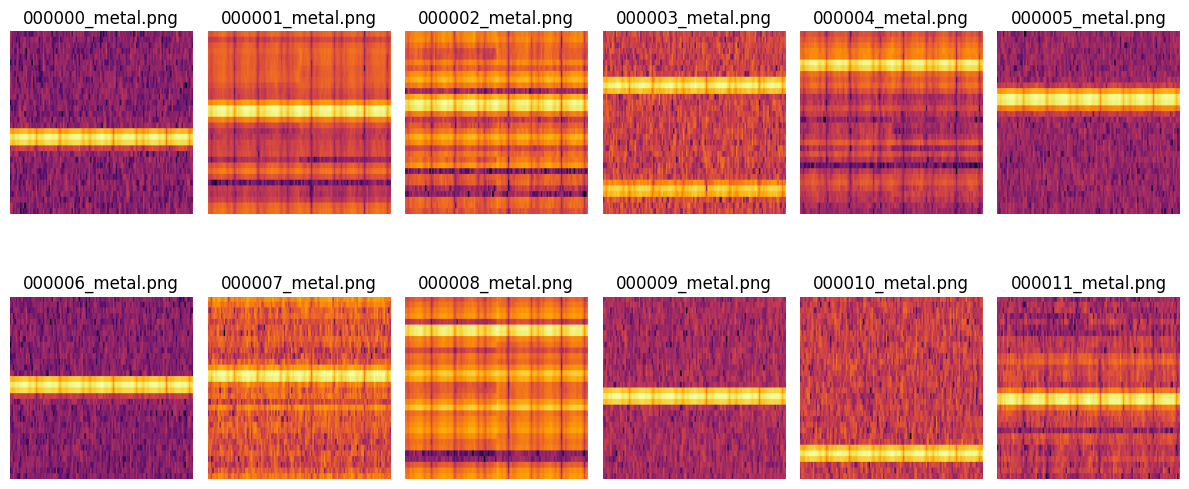

In [4]:
# generate_radar_dataset.py
import os
import json
from pathlib import Path
import numpy as np
from numpy.fft import fft, ifft, fftshift, fftfreq
import matplotlib.pyplot as plt
from tqdm import tqdm
import imageio
import cv2

# ---------------------------
# Configurable parameters
# ---------------------------
SEED = 42
np.random.seed(SEED)

OUT_DIR = Path("artifact")
HEATMAP_DIR = OUT_DIR / "heatmaps"
RADAR_DIR = OUT_DIR / "radar_signals"
MODEL_DIR = OUT_DIR / "models"
LABEL_FILE = OUT_DIR / "labels.json"

OUT_DIR.mkdir(exist_ok=True)
HEATMAP_DIR.mkdir(parents=True, exist_ok=True)
RADAR_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

# Radar waveform params (realistic FMCW example)
c = 3e8                        # speed of light
fc = 24e9                      # carrier frequency in Hz (24 GHz)
B = 200e6                      # sweep bandwidth in Hz (200 MHz)
T_chirp = 1e-3                 # chirp duration in seconds (1 ms)
samples_per_chirp = 512        # fast-time samples per chirp (range bins)
N_pulses = 32                  # slow-time samples per frame (Doppler bins)
fs = samples_per_chirp / T_chirp  # fast-time sampling rate
slope = B / T_chirp
lambda_c = c / fc
PRF = 1 / (T_chirp + 1e-4)     # pulse repetition (approx), keep > N_pulses/T_frame

# Dataset params
NUM_PER_CLASS = 300            # number of samples per class (metal / nonmetal)
OUTPUT_IMG_SIZE = (128, 128)   # final saved image size
SAVE_RAW_SIGNAL = True         # save raw IQ frames as .npy to RADAR_DIR
NORMALIZE_GLOBAL = True        # normalize heatmaps to 0-255 single step

# Noise/Clutter defaults
DEFAULT_SNR_DB = 20            # overall SNR for signals
CLUTTER_DENSITY = (5, 20)      # number of clutter scatterers when clutter is on
CLUTTER_RCS_RANGE = (0.05, 0.5) # clutter reflectivity range
METAL_RCS_RANGE = (1.0, 3.0)   # metal RCS amplitude range
NONMETAL_RCS_RANGE = (0.2, 0.6) # nonmetal weak reflectivity (if single target used)
MAX_RANGE_METERS = 50.0        # maximum simulated range
MIN_RANGE_METERS = 2.0

# ---------------------------
# Utility functions
# ---------------------------
def generate_fmcw_chirp(samples=samples_per_chirp, fc=fc, B=B, T=T_chirp):
    """
    Generate a complex baseband FMCW chirp (passband) sample vector.
    s(t) = exp(j*2*pi*(f0*t + 0.5*k*t^2))
    """
    t = np.linspace(0, T, samples, endpoint=False)
    k = B / T
    phase = 2 * np.pi * (fc * t + 0.5 * k * t**2)
    return np.exp(1j * phase)

def fractional_delay_freqdomain(sig, delay_seconds, fs):
    """
    Apply fractional delay to signal using frequency-domain linear phase shift.
    delay_seconds: positive = delayed (signal appears later)
    """
    N = len(sig)
    SIG = fft(sig)
    freqs = fftfreq(N, d=1.0/fs)  # cycles/sec
    phase_shift = np.exp(-1j * 2 * np.pi * freqs * delay_seconds)
    SIG_shifted = SIG * phase_shift
    delayed = ifft(SIG_shifted)
    return delayed

def add_awgn(signal, target_snr_db):
    """
    Add complex AWGN to complex signal (per-frame).
    target_snr_db is SNR relative to signal power (not per-sample).
    """
    sig_power = np.mean(np.abs(signal)**2)
    noise_power = sig_power / (10**(target_snr_db / 10))
    noise = np.sqrt(noise_power/2) * (np.random.randn(*signal.shape) + 1j*np.random.randn(*signal.shape))
    return signal + noise

def compute_range_doppler(frame_iq, window=True):
    """
    frame_iq: shape (N_pulses, samples_per_chirp) complex matrix
    Returns dB-scaled range-doppler map (2D array): shape (N_pulses, samples_per_chirp) with Doppler axis fftshifted.
    """
    # 2D windowing (Hann)
    if window:
        win_fast = np.hanning(frame_iq.shape[1])
        win_slow = np.hanning(frame_iq.shape[0])
        frame_win = frame_iq * win_fast[None, :] * win_slow[:, None]
    else:
        frame_win = frame_iq

    # Range FFT (fast-time) along axis=1
    range_fft = fft(frame_win, axis=1)
    # Doppler FFT (slow-time) along axis=0, then shift so zero Doppler in center
    rd = fftshift(fft(range_fft, axis=0), axes=0)
    rd_mag = np.abs(rd)
    rd_db = 20 * np.log10(rd_mag + 1e-10)
    return rd_db

# ---------------------------
# Scene & frame generation
# ---------------------------
def simulate_frame(targets, clutter=False, snr_db=DEFAULT_SNR_DB):
    """
    Simulate a single radar frame.
    targets: list of dicts { 'range_m':, 'velocity_mps':, 'rcs': }
    clutter: bool (whether to add random weak scatterers)
    Returns complex IQ frame shape (N_pulses, samples_per_chirp)
    """
    tx_chirp = generate_fmcw_chirp()
    frame = np.zeros((N_pulses, samples_per_chirp), dtype=np.complex64)

    for p in range(N_pulses):
        # Start with noise-free transmitted chirp (we only need received echoes)
        rx_total = np.zeros(samples_per_chirp, dtype=np.complex64)

        # per-target echo
        for tgt in targets:
            R = tgt['range_m']
            v = tgt['velocity_mps']
            amp = tgt['rcs']

            # round-trip delay
            tau = 2.0 * R / c   # seconds
            # Doppler frequency (Hz)
            fd = 2.0 * v / lambda_c

            # fractional delay of chirp for this target
            delayed = fractional_delay_freqdomain(tx_chirp, tau, fs)

            # Doppler phase across pulses: apply slow-time phase (constant across fast-time)
            t_slow = p / PRF
            doppler_phase = np.exp(1j * 2 * np.pi * fd * t_slow)

            rx_echo = amp * delayed * doppler_phase
            rx_total += rx_echo

        # clutter scatterers (many weak targets)
        if clutter:
            num_clutter = np.random.randint(CLUTTER_DENSITY[0], CLUTTER_DENSITY[1]+1)
            for _ in range(num_clutter):
                R_c = np.random.uniform(MIN_RANGE_METERS, MAX_RANGE_METERS)
                v_c = np.random.uniform(-0.5, 0.5)
                rcs_c = np.random.uniform(CLUTTER_RCS_RANGE[0], CLUTTER_RCS_RANGE[1])
                tau_c = 2.0 * R_c / c
                fd_c = 2.0 * v_c / lambda_c
                delayed_c = fractional_delay_freqdomain(tx_chirp, tau_c, fs)
                doppler_phase_c = np.exp(1j * 2 * np.pi * fd_c * (p / PRF))
                rx_total += rcs_c * delayed_c * doppler_phase_c

        # Add AWGN to reach desired frame SNR
        rx_total = add_awgn(rx_total, snr_db)
        frame[p, :] = rx_total

    return frame

# ---------------------------
# Dataset generation
# ---------------------------
def generate_dataset(num_per_class=NUM_PER_CLASS, save_raw=SAVE_RAW_SIGNAL):
    """
    Generate a balanced dataset with 'metal' and 'nonmetal' classes.
    Returns metadata list and writes files to disk.
    """
    meta = []
    sample_idx = 0

    # loop for classes
    for cls in ["metal", "nonmetal"]:
        for i in tqdm(range(num_per_class), desc=f"Generating {cls}"):
            # Randomize SNR and clutter presence (both classes get clutter sometimes)
            snr_db = int(np.random.choice([10, 15, 20, 25]))
            clutter_flag = np.random.choice([True, False], p=[0.5, 0.5])

            targets = []
            if cls == "metal":
                # place 1-2 strong metal targets
                n_targets = np.random.choice([1, 2], p=[0.8, 0.2])
                for _ in range(n_targets):
                    R = float(np.random.uniform(5.0, MAX_RANGE_METERS))
                    v = float(np.random.uniform(-2.0, 2.0))
                    rcs = float(np.random.uniform(METAL_RCS_RANGE[0], METAL_RCS_RANGE[1]))
                    targets.append({'range_m': R, 'velocity_mps': v, 'rcs': rcs})
            else:
                # Nonmetal: either no distinct strong target (only clutter) OR weak diffuse target(s)
                if np.random.rand() < 0.5:
                    targets = []  # pure clutter / empty
                else:
                    # weak single target
                    R = float(np.random.uniform(5.0, MAX_RANGE_METERS))
                    v = float(np.random.uniform(-1.0, 1.0))
                    rcs = float(np.random.uniform(NONMETAL_RCS_RANGE[0], NONMETAL_RCS_RANGE[1]))
                    targets.append({'range_m': R, 'velocity_mps': v, 'rcs': rcs})

            # Simulate frame
            frame = simulate_frame(targets, clutter=clutter_flag, snr_db=snr_db)

            # Compute range-doppler map
            rd_db = compute_range_doppler(frame)

            # Convert to image: normalize once globally per-sample (not per-pixel across dataset)
            # We'll map to 0-255 based on this image's min/max to preserve contrast (but keep consistent later if desired).
            # To avoid extreme clipping, clip dynamic range to some dB span e.g., top - 80 dB
            rd_db_clipped = np.clip(rd_db, a_min=rd_db.max() - 80.0, a_max=rd_db.max())
            img = rd_db_clipped - rd_db_clipped.min()
            img = img / (img.max() + 1e-12)
            img_uint8 = (img * 255.0).astype(np.uint8)

            # Resize to OUTPUT_IMG_SIZE using INTER_AREA (good for downsampling)
            img_resized = cv2.resize(img_uint8, OUTPUT_IMG_SIZE, interpolation=cv2.INTER_AREA)

            # Filepaths
            fname_base = f"{sample_idx:06d}_{cls}"
            img_fp = HEATMAP_DIR / f"{fname_base}.png"
            npy_fp = RADAR_DIR / f"{fname_base}.npy"

            # Save image and optionally raw IQ
            imageio.imwrite(str(img_fp), img_resized)
            if save_raw:
                np.save(str(npy_fp), frame)

            # Save metadata entry
            meta_entry = {
                "file": str(img_fp),
                "raw_signal": str(npy_fp) if save_raw else None,
                "class": cls,
                "snr_db": int(snr_db),
                "clutter": bool(clutter_flag),
                "targets": targets
            }
            meta.append(meta_entry)

            sample_idx += 1

    # Optionally do a final global normalization step across the dataset if desired.
    # For now we kept per-sample normalization to preserve dynamic range per image.

    # Write metadata file
    with open(LABEL_FILE, "w") as f:
        json.dump(meta, f, indent=2)

    print(f"Dataset generation completed. Total samples: {len(meta)}")
    return meta

# ---------------------------
# Quick visualization helper
# ---------------------------
def show_examples(n=12):
    files = sorted(HEATMAP_DIR.glob("*.png"))[:n]
    plt.figure(figsize=(12, 6))
    ncols = min(6, n)
    for idx, fp in enumerate(files):
        plt.subplot(int(np.ceil(n/ncols)), ncols, idx+1)
        plt.imshow(imageio.imread(fp), cmap="inferno")
        plt.title(fp.name)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

# ---------------------------
# Run dataset generation (main)
# ---------------------------
if __name__ == "__main__":
    # small sanity-run: create a smaller dataset if you want
    # meta = generate_dataset(num_per_class=10, save_raw=True)

    # For full: generate NUM_PER_CLASS per class
    meta = generate_dataset(num_per_class=NUM_PER_CLASS, save_raw=SAVE_RAW_SIGNAL)

    # show a few examples
    show_examples(n=12)
